# Pain / No-Pain Binary Classifier
**End-to-end pipeline:** `.npy` log-mel spectrograms (128×94) → CNN → pain / no-pain prediction

Run cells top to bottom. No intermediate files needed.

**Directory layout expected:**
```
Data/all-pain/npy/pain/      ← label 1 (pain)
Data/all-pain/npy/no-pain/   ← label 0 (no pain)
```


## 1. Imports & Config

we utilize data balancing to try and standardize the classes with about 700 to 750 of data values in each class training on all pain

In [22]:
import os, glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score,
                              RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paths ──────────────────────────────────────────────────────────────────
PAIN_DIR    = "../Data/all-pain/npy/pain"
NO_PAIN_DIR = "../Data/all-pain/npy/no-pain"
EXPECTED_SHAPE = (128, 94)

# ── Hyperparameters ────────────────────────────────────────────────────────
TEST_SIZE     = 0.20
RANDOM_STATE  = 42
BATCH_SIZE    = 32
EPOCHS        = 20
LEARNING_RATE = 1e-3

# threshold
threshold = 0.48

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")


Device : cpu


## 2. Data Loading

In [23]:
def load_npy_files(folder, label):
    paths = sorted(glob.glob(os.path.join(folder, "*.npy")))
    if not paths:
        raise FileNotFoundError(f"No .npy files found in: {folder}")
    arrays, labels, skipped = [], [], 0
    for p in paths:
        arr = np.load(p)
        if arr.shape != EXPECTED_SHAPE:
            print(f"  [SKIP] {os.path.basename(p)} — shape {arr.shape} ≠ {EXPECTED_SHAPE}")
            skipped += 1
            continue
        arrays.append(arr.astype(np.float32))
        labels.append(label)
    print(f"  Loaded {len(arrays):>4d} files from '{folder}'  (skipped {skipped})")
    return arrays, labels

print("Loading files …")
pain_X,    pain_y    = load_npy_files(PAIN_DIR,    label=1)
no_pain_X, no_pain_y = load_npy_files(NO_PAIN_DIR, label=0)

# ── Balance the dataset by downsampling the larger no-pain class ───────────
# Your pain class has about 704 files, while no-pain has thousands.
# Keeping only 750 random no-pain files prevents the model from learning
# the lazy shortcut: "guess no-pain most of the time."
NO_PAIN_SAMPLE_SIZE = 750
rng = np.random.default_rng(RANDOM_STATE)

if len(no_pain_X) > NO_PAIN_SAMPLE_SIZE:
    keep_idx = rng.choice(len(no_pain_X), size=NO_PAIN_SAMPLE_SIZE, replace=False)
    no_pain_X = [no_pain_X[i] for i in keep_idx]
    no_pain_y = [no_pain_y[i] for i in keep_idx]
    print(f"  Downsampled no-pain files to {len(no_pain_X)}")
else:
    print(f"  No-pain has only {len(no_pain_X)} files, so no downsampling was applied")

X_all = np.array(pain_X + no_pain_X, dtype=np.float32)
y_all = np.array(pain_y + no_pain_y, dtype=np.float32)

print(f"\nTotal : {len(X_all)}  |  Pain={int(y_all.sum())}  No-pain={int((y_all==0).sum())}")



Loading files …
  Loaded  775 files from '../Data/all-pain/npy/pain'  (skipped 0)
  Loaded 6682 files from '../Data/all-pain/npy/no-pain'  (skipped 0)
  Downsampled no-pain files to 750

Total : 1525  |  Pain=775  No-pain=750


## 2b. Silence Analysis

Average silence ratio : 46.70%
Samples >90% silence  : 33
Samples >50% silence  : 779


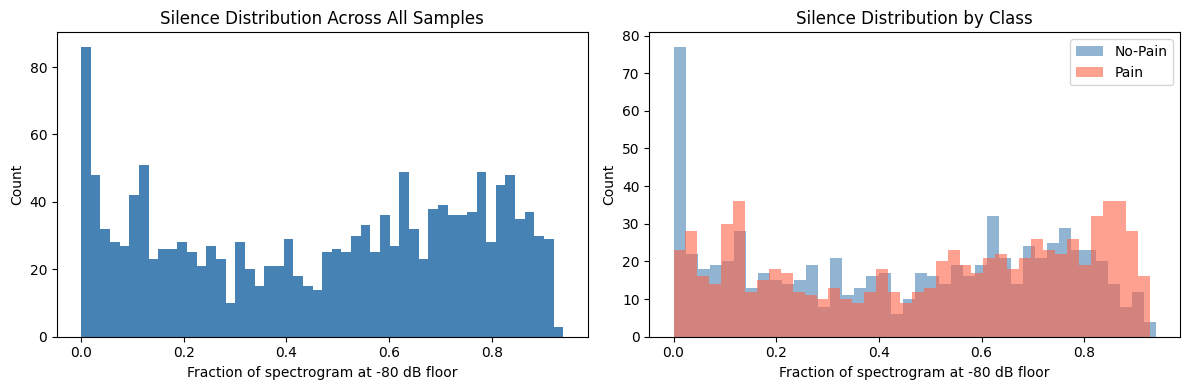

In [24]:
# Check how much of each spectrogram is at the -80 dB silence floor
silence_ratio = (X_all <= -79).mean(axis=(1, 2))

print(f"Average silence ratio : {silence_ratio.mean():.2%}")
print(f"Samples >90% silence  : {(silence_ratio > 0.9).sum()}")
print(f"Samples >50% silence  : {(silence_ratio > 0.5).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(silence_ratio, bins=50, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Fraction of spectrogram at -80 dB floor")
axes[0].set_ylabel("Count")
axes[0].set_title("Silence Distribution Across All Samples")

# Split by class
axes[1].hist(silence_ratio[y_all == 0], bins=40, alpha=0.6, label="No-Pain", color="steelblue")
axes[1].hist(silence_ratio[y_all == 1], bins=40, alpha=0.6, label="Pain",    color="tomato")
axes[1].set_xlabel("Fraction of spectrogram at -80 dB floor")
axes[1].set_ylabel("Count")
axes[1].set_title("Silence Distribution by Class")
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. Exploration

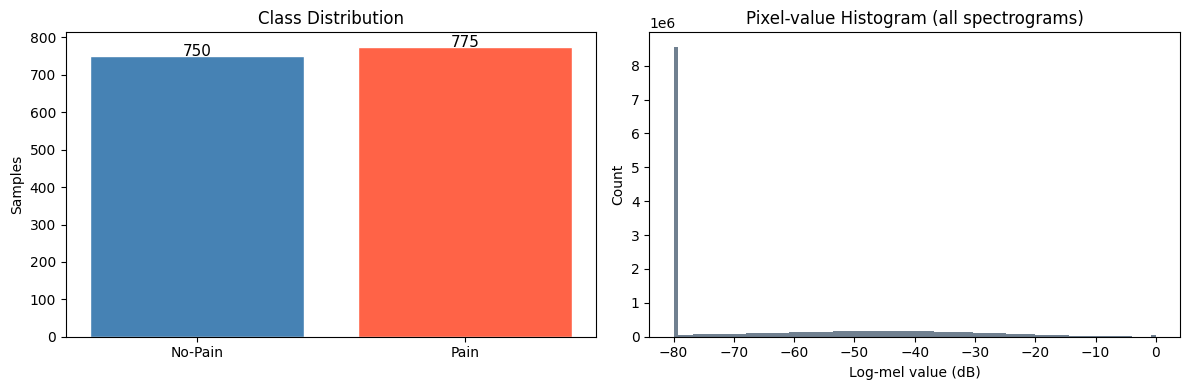

Value range : [-80.0, 0.0]  mean=-61.65  std=21.17


In [25]:
# Class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = [int((y_all==0).sum()), int(y_all.sum())]
axes[0].bar(["No-Pain", "Pain"], counts, color=["steelblue", "tomato"], edgecolor="white")
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=11)
axes[0].set_title("Class Distribution"); axes[0].set_ylabel("Samples")

# Value histogram
axes[1].hist(X_all.flatten(), bins=100, color="slategray", edgecolor="none")
axes[1].set_title("Pixel-value Histogram (all spectrograms)")
axes[1].set_xlabel("Log-mel value (dB)"); axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()

print(f"Value range : [{X_all.min():.1f}, {X_all.max():.1f}]  "
      f"mean={X_all.mean():.2f}  std={X_all.std():.2f}")


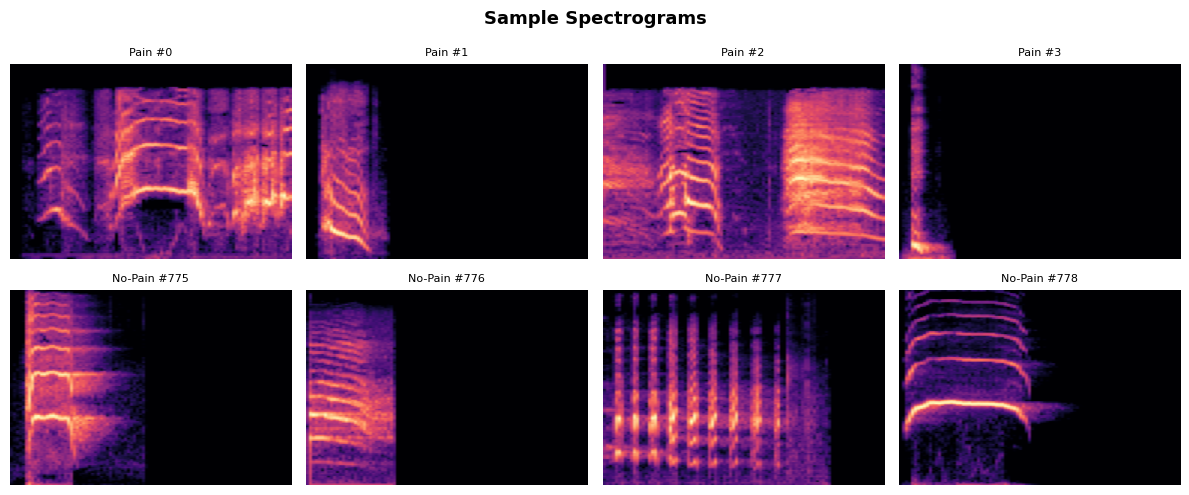

In [26]:
# Sample spectrograms
n = 4
pain_idx    = np.where(y_all == 1)[0][:n]
no_pain_idx = np.where(y_all == 0)[0][:n]

fig, axes = plt.subplots(2, n, figsize=(12, 5))
fig.suptitle("Sample Spectrograms", fontsize=13, fontweight="bold")
for col in range(n):
    for row, (idx, title) in enumerate([(pain_idx[col], "Pain"),
                                         (no_pain_idx[col], "No-Pain")]):
        axes[row, col].imshow(X_all[idx], aspect="auto", origin="lower", cmap="magma")
        axes[row, col].set_title(f"{title} #{idx}", fontsize=8)
        axes[row, col].axis("off")
axes[0, 0].set_ylabel("Pain",    fontsize=10)
axes[1, 0].set_ylabel("No-Pain", fontsize=10)
plt.tight_layout(); plt.show()


## 4. Preprocessing

In [27]:
# Normalise (zero-mean / unit-variance)
X_mean = X_all.mean()
X_std  = X_all.std() + 1e-8
X_norm = (X_all - X_mean) / X_std

# Add channel dim → (N, 1, 128, 94) for PyTorch
X_norm = X_norm[:, np.newaxis, :, :]

print(f"Shape : {X_norm.shape}  (N, C, mel_bins, time_frames)")
print(f"Normalised  →  mean≈{X_norm.mean():.4f}  std≈{X_norm.std():.4f}")
print(f"Norm stats saved in memory  (mean={X_mean:.4f}, std={X_std:.4f})")


Shape : (1525, 1, 128, 94)  (N, C, mel_bins, time_frames)
Normalised  →  mean≈-0.0000  std≈1.0000
Norm stats saved in memory  (mean=-61.6499, std=21.1661)


## 5. Train / Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_all,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_all
)

print(f"Train : {len(X_train)}  |  pain={int(y_train.sum())}  no-pain={int((y_train==0).sum())}")
print(f"Test  : {len(X_test)}   |  pain={int(y_test.sum())}   no-pain={int((y_test==0).sum())}")


Train : 1220  |  pain=620  no-pain=600
Test  : 305   |  pain=155   no-pain=150


## 6. Dataset & DataLoaders

In [29]:
class SpectrogramDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(1)
        self.augment = augment

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        x, y = self.X[idx].clone(), self.y[idx]
        if self.augment:
            t = np.random.randint(0, 10)
            t0 = np.random.randint(0, 94 - t)
            x[:, :, t0:t0+t] = 0
            f = np.random.randint(0, 15)
            f0 = np.random.randint(0, 128 - f)
            x[:, f0:f0+f, :] = 0
            x += torch.randn_like(x) * 0.01
        return x, y

train_loader = DataLoader(SpectrogramDataset(X_train, y_train, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(SpectrogramDataset(X_test,  y_test,  augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


## 7. Model

| Block | Output shape |
|---|---|
| Input | (B, 1, 128, 94) |
| Conv32 + BN + ReLU + MaxPool | (B, 32, 64, 47) |
| Conv64 + BN + ReLU + MaxPool | (B, 64, 32, 23) |
| Conv128 + BN + ReLU + MaxPool | (B, 128, 16, 11) |
| FC 256 + Dropout(0.4) | (B, 256) |
| Output logit | (B, 1) |


In [30]:
class PainCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1,   32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Dropout2d(0.2))
        self.block2 = nn.Sequential(
            nn.Conv2d(32,  64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Dropout2d(0.2))
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Dropout2d(0.2))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 11, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1))

    def forward(self, x):
        return self.classifier(self.block3(self.block2(self.block1(x))))

model = PainCNN().to(DEVICE)

# Sanity check
dummy = torch.zeros(2, 1, 128, 94).to(DEVICE)
assert model(dummy).shape == (2, 1), "Output shape mismatch!"
print("Forward pass OK")
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {total:,}")


Forward pass OK
Trainable parameters : 5,860,801


## 8. Training

In [31]:
# ── Loss setup ─────────────────────────────────────────────────────────────
num_no_pain = int((y_train == 0).sum())
num_pain    = int((y_train == 1).sum())
pos_weight  = torch.tensor([num_no_pain / num_pain]).to(DEVICE)
print(f"Class counts  →  no-pain={num_no_pain}  pain={num_pain}")
print(f"pos_weight    →  {pos_weight.item():.3f}  (near 1 because no-pain was downsampled)")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            preds    = (torch.sigmoid(logits) >= threshold).float()
            correct += (preds == yb).sum().item()
            total   += yb.size(0)
            total_loss += loss.item() * yb.size(0)
    return total_loss / total, correct / total

# ── Training loop with early stopping ─────────────────────────────────────
PATIENCE          = 5
best_val_loss     = float("inf")
epochs_no_improve = 0
history           = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print(f"\n{'Epoch':>6} | {'Train Loss':>10} {'Train Acc':>10} | {'Val Loss':>9} {'Val Acc':>9}")
print("-" * 58)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(test_loader,  train=False)
    scheduler.step(va_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    marker = "<-- best" if va_loss < best_val_loss else ""
    if va_loss < best_val_loss:
        best_val_loss     = va_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_pain_cnn.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}")
            break

    print(f"{epoch:>6} | {tr_loss:>10.4f} {tr_acc:>10.4f} | "
          f"{va_loss:>9.4f} {va_acc:>9.4f}{marker}")

print(f"\nBest validation loss : {best_val_loss:.4f}")



Class counts  →  no-pain=600  pain=620
pos_weight    →  0.968  (near 1 because no-pain was downsampled)

 Epoch | Train Loss  Train Acc |  Val Loss   Val Acc
----------------------------------------------------------
     1 |     1.9616     0.5131 |    0.6800    0.5738<-- best
     2 |     0.6775     0.5770 |    0.6653    0.5279<-- best
     3 |     0.6589     0.5934 |    0.6496    0.7279<-- best
     4 |     0.6557     0.6123 |    0.6226    0.6492<-- best
     5 |     0.6510     0.6164 |    0.6373    0.6721
     6 |     0.6423     0.6303 |    0.6104    0.6852<-- best
     7 |     0.6314     0.6311 |    0.6144    0.6689
     8 |     0.6335     0.6426 |    0.6145    0.6426
     9 |     0.6350     0.6221 |    0.6230    0.7049
    10 |     0.6120     0.6566 |    0.5908    0.7082<-- best
    11 |     0.6070     0.6697 |    0.5861    0.6951<-- best
    12 |     0.5994     0.6795 |    0.5741    0.6984<-- best
    13 |     0.5933     0.6730 |    0.5724    0.7049<-- best
    14 |     0.5955   

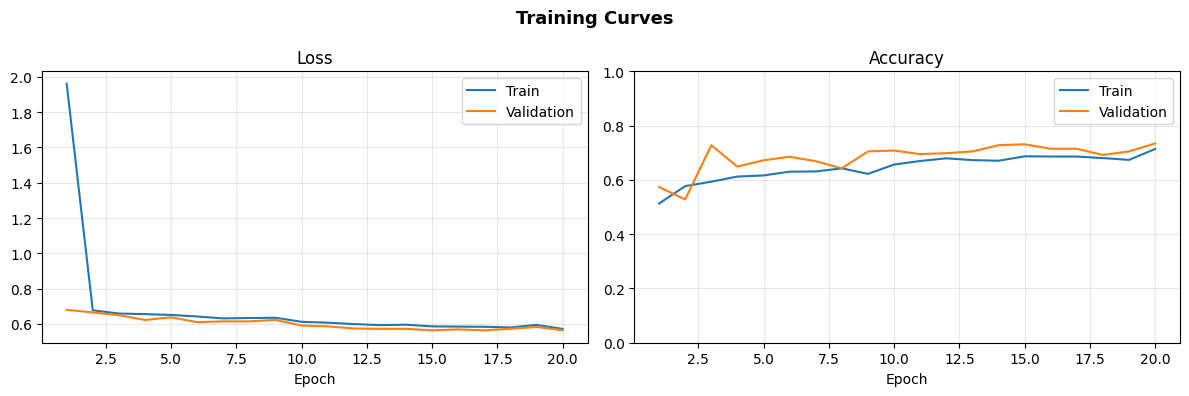

In [32]:
# Training curves
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Training Curves", fontsize=13, fontweight="bold")

ax1.plot(epochs_range, history["train_loss"], label="Train")
ax1.plot(epochs_range, history["val_loss"],   label="Validation")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history["train_acc"], label="Train")
ax2.plot(epochs_range, history["val_acc"],   label="Validation")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch")
ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.savefig("training_curves.png", dpi=130); plt.show()


## 9. Evaluation

In [33]:
# Load best checkpoint
model.load_state_dict(torch.load("best_pain_cnn.pt", map_location=DEVICE))
model.eval()

all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        probs = torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_preds.extend((probs >= threshold).astype(int))
        all_labels.extend(yb.numpy().flatten().astype(int))

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
cm  = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

print(f"Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"ROC-AUC  : {roc_auc_score(all_labels, all_probs):.4f}")
print()
print(classification_report(all_labels, all_preds,
                            target_names=["No-Pain", "Pain"], digits=4))
print(f"Sensitivity (recall pain)     : {tp/(tp+fn+1e-8):.4f}")
print(f"Specificity (recall no-pain)  : {tn/(tn+fp+1e-8):.4f}")

# Bias check
drift = abs(all_preds.mean() - all_labels.mean())
flag  = "Possible class bias — consider rebalancing." if drift > 0.15 else "Class distribution looks healthy."
print(f"\nPredicted pain rate: {all_preds.mean():.4f}  |  Actual: {all_labels.mean():.4f}  →  {flag}")


Accuracy : 0.7148  (71.48%)
ROC-AUC  : 0.8085

              precision    recall  f1-score   support

     No-Pain     0.7647    0.6067    0.6766       150
        Pain     0.6828    0.8194    0.7449       155

    accuracy                         0.7148       305
   macro avg     0.7238    0.7130    0.7107       305
weighted avg     0.7231    0.7148    0.7113       305

Sensitivity (recall pain)     : 0.8194
Specificity (recall no-pain)  : 0.6067

Predicted pain rate: 0.6098  |  Actual: 0.5082  →  Class distribution looks healthy.


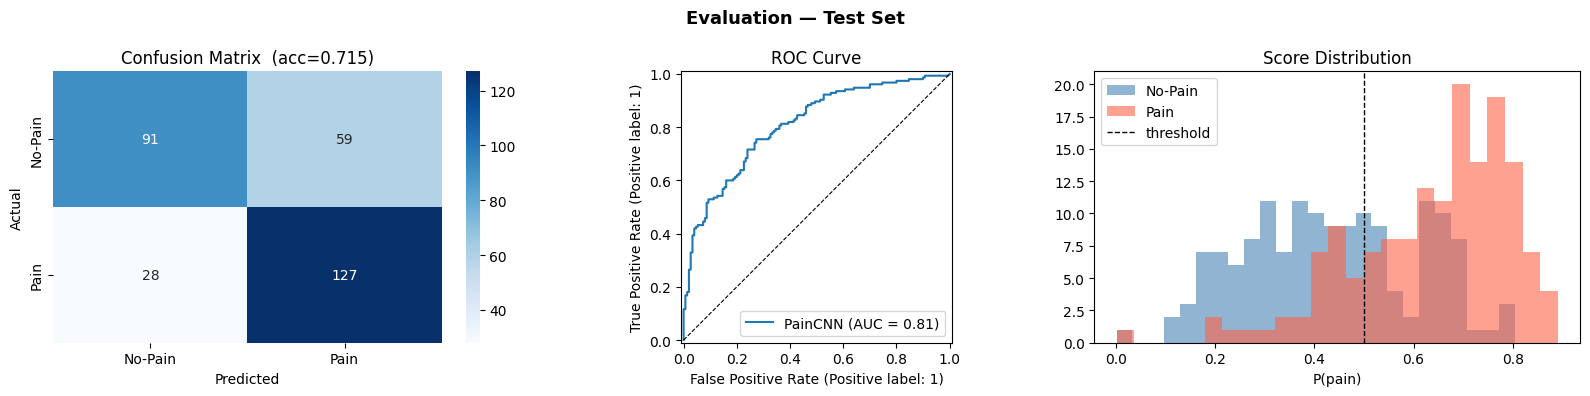

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Evaluation — Test Set", fontsize=13, fontweight="bold")

# Confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No-Pain","Pain"], yticklabels=["No-Pain","Pain"])
axes[0].set_title(f"Confusion Matrix  (acc={acc:.3f})")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# ROC curve
RocCurveDisplay.from_predictions(all_labels, all_probs, name="PainCNN", ax=axes[1])
axes[1].plot([0,1],[0,1],"k--",linewidth=0.8)
axes[1].set_title("ROC Curve")

# Score distribution
axes[2].hist(all_probs[all_labels==0], bins=25, alpha=0.6, label="No-Pain", color="steelblue")
axes[2].hist(all_probs[all_labels==1], bins=25, alpha=0.6, label="Pain",    color="tomato")
axes[2].axvline(0.5, color="black", linestyle="--", linewidth=1, label="threshold")
axes[2].set_xlabel("P(pain)"); axes[2].set_title("Score Distribution"); axes[2].legend()

plt.tight_layout() 
# plt.savefig("evaluation.png", dpi=130); 
plt.show()


Youden's J  →  threshold=0.537  sensitivity=0.755  specificity=0.727
Sensitivity≥0.9  →  threshold=0.414  sensitivity=0.923  specificity=0.473
Best F1     →  threshold=0.414  f1=0.759


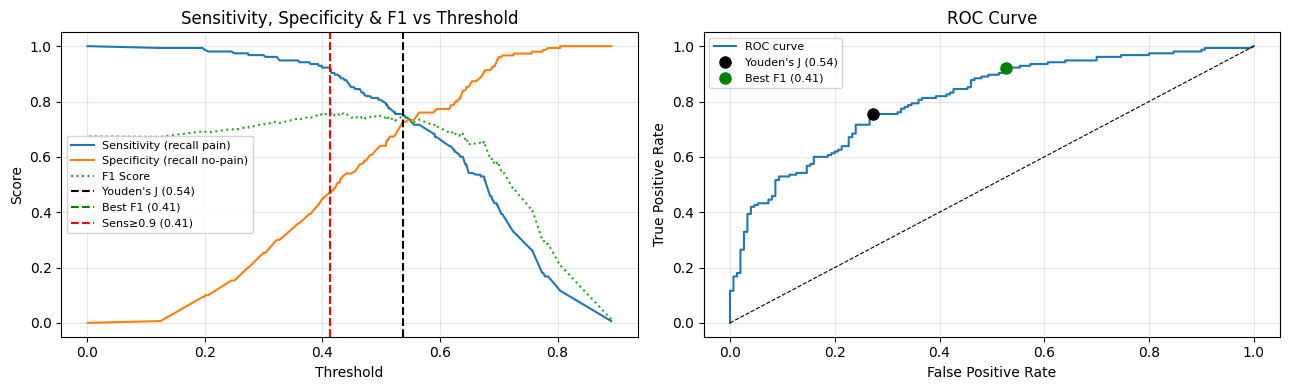


At threshold=0.537:
F1 at this threshold : 0.7476
              precision    recall  f1-score   support

     No-Pain     0.7415    0.7267    0.7340       150
        Pain     0.7405    0.7548    0.7476       155

    accuracy                         0.7410       305
   macro avg     0.7410    0.7408    0.7408       305
weighted avg     0.7410    0.7410    0.7409       305



In [35]:
from sklearn.metrics import roc_curve, f1_score

# Get all possible thresholds from the ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# ── Option 1: Youden's J (maximises sensitivity + specificity equally) ──
j_scores         = tpr - fpr
best_idx_j       = j_scores.argmax()
best_threshold_j = thresholds[best_idx_j]
print(f"Youden's J  →  threshold={best_threshold_j:.3f}  "
      f"sensitivity={tpr[best_idx_j]:.3f}  specificity={1-fpr[best_idx_j]:.3f}")

# ── Option 2: Minimise missed pain (maximise sensitivity) ──────────────
min_sensitivity = 0.90
mask = tpr >= min_sensitivity
if mask.any():
    best_idx_sens    = (tpr[mask] - fpr[mask]).argmax()
    best_threshold_sens = thresholds[mask][best_idx_sens]
    print(f"Sensitivity≥{min_sensitivity}  →  threshold={best_threshold_sens:.3f}  "
          f"sensitivity={tpr[mask][best_idx_sens]:.3f}  "
          f"specificity={1-fpr[mask][best_idx_sens]:.3f}")

# ── Option 3: Maximise F1 score ────────────────────────────────────────
f1_scores         = [f1_score(all_labels, (all_probs >= t).astype(int), zero_division=0)
                     for t in thresholds]
best_idx_f1       = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_idx_f1]
print(f"Best F1     →  threshold={best_threshold_f1:.3f}  "
      f"f1={f1_scores[best_idx_f1]:.3f}")

# ── Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sensitivity, specificity & F1 vs threshold
axes[0].plot(thresholds, tpr,       label="Sensitivity (recall pain)")
axes[0].plot(thresholds, 1 - fpr,   label="Specificity (recall no-pain)")
axes[0].plot(thresholds, f1_scores, label="F1 Score", linestyle=":")
axes[0].axvline(best_threshold_j,   color="black", linestyle="--", label=f"Youden's J ({best_threshold_j:.2f})")
axes[0].axvline(best_threshold_f1,  color="green", linestyle="--", label=f"Best F1 ({best_threshold_f1:.2f})")
if mask.any():
    axes[0].axvline(best_threshold_sens, color="red", linestyle="--",
                    label=f"Sens≥{min_sensitivity} ({best_threshold_sens:.2f})")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Sensitivity, Specificity & F1 vs Threshold")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ROC curve with best point marked
axes[1].plot(fpr, tpr, label="ROC curve")
axes[1].plot(fpr[best_idx_j], tpr[best_idx_j], "ko", markersize=8,
             label=f"Youden's J ({best_threshold_j:.2f})")
axes[1].plot(fpr[best_idx_f1], tpr[best_idx_f1], "go", markersize=8,
             label=f"Best F1 ({best_threshold_f1:.2f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Evaluate at chosen threshold ───────────────────────────────────────
THRESHOLD          = best_threshold_j   # ← swap to best_threshold_f1 or best_threshold_sens
preds_at_threshold = (all_probs >= THRESHOLD).astype(int)
print(f"\nAt threshold={THRESHOLD:.3f}:")
print(f"F1 at this threshold : {f1_score(all_labels, preds_at_threshold):.4f}")
print(classification_report(all_labels, preds_at_threshold,
                             target_names=["No-Pain", "Pain"], digits=4))

## 10. Inference on New Files

In [36]:
def predict_single(npy_path: str) -> dict:
    """
    Predict pain / no-pain for a single .npy spectrogram.

    Returns dict: { label, prob_pain, pred }
    """
    arr = np.load(npy_path).astype(np.float32)
    assert arr.shape == EXPECTED_SHAPE, f"Expected {EXPECTED_SHAPE}, got {arr.shape}"
    arr    = (arr - X_mean) / (X_std + 1e-8)
    tensor = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).item()
    pred = int(prob >= threshold)
    return {"label": "pain" if pred else "no-pain", "prob_pain": round(prob, 4), "pred": pred}


# ── Example ────────────────────────────────────────────────────────────────
# result = predict_single("Data/clean-pain-only/npy/pain/sample.npy")
# print(result)   # {'label': 'pain', 'prob_pain': 0.91, 'pred': 1}


In [37]:
import pandas as pd

def predict_folder(folder: str) -> pd.DataFrame:
    """Run inference on every .npy file in *folder*."""
    paths = sorted(glob.glob(os.path.join(folder, "*.npy")))
    rows  = []
    for p in paths:
        try:
            rows.append({"file": os.path.basename(p), **predict_single(p)})
        except Exception as e:
            rows.append({"file": os.path.basename(p), "error": str(e)})
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    return df

# ── Example ────────────────────────────────────────────────────────────────
# df = predict_folder("Data/clean-pain-only/npy/pain")
# df.to_csv("predictions.csv", index=False)


## 11. Inference

In [38]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

class MelConverter:
    def __init__(self,
        sample_rate=16000,
        duration=3,
        n_fft=1024,
        hop_length=512,
        n_mels=128
    ):
        self.sample_rate = sample_rate
        self.duration = duration
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels

    def load_audio(self, audio_path):
        y, sr = librosa.load(audio_path, sr=self.sample_rate, mono=True)
        return y, sr

    def fix_length(self, y):
        target_length = self.sample_rate * self.duration
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)))
        else:
            y = y[:target_length]
        return y

    def to_log_mel(self, y, sr):
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=self.n_fft,
            hop_length=self.hop_length, n_mels=self.n_mels
        )
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        return log_mel_spec

Spectrogram shape : (128, 94)

── Result ────────────────────────────────
  Prediction  : NO PAIN
  Certainty   : CONFIDENT
  P(pain)     : 0.2645
  P(no-pain)  : 0.7355
  Threshold   : 0.480
──────────────────────────────────────────


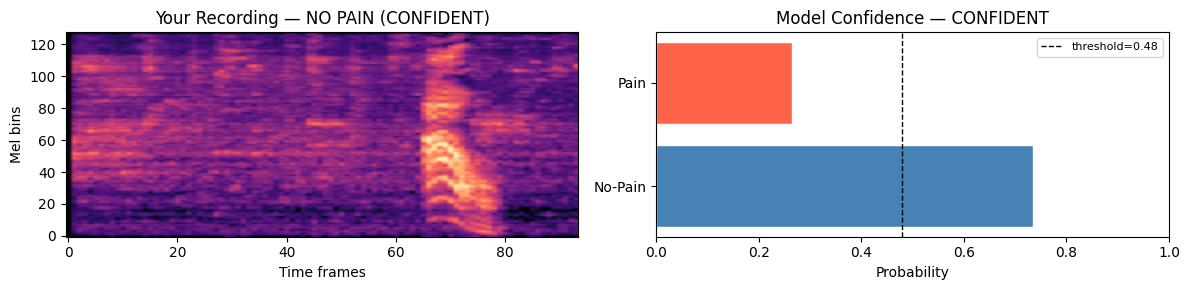

In [46]:
# ── Set your path here ────────────────────────────────────────────────────
INPUT_WAV = "../Data-Conversion/noisybackground1.wav"   # ← your wav file

# ── Step 1: Convert wav → log-mel ─────────────────────────────────────────
converter = MelConverter()
y, sr     = converter.load_audio(INPUT_WAV)
y         = converter.fix_length(y)
log_mel   = converter.to_log_mel(y, sr)
print(f"Spectrogram shape : {log_mel.shape}")

# ── Step 2: Normalise and pass to model ───────────────────────────────────
arr    = (log_mel.astype(np.float32) - X_mean) / (X_std + 1e-8)
tensor = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).to(DEVICE)

model.eval()
with torch.no_grad():
    prob = torch.sigmoid(model(tensor)).item()

p_pain    = prob
p_no_pain = 1 - prob

# ── Decision logic ─────────────────────────────────────────────────────────
if p_pain >= threshold and p_no_pain >= threshold:
    # Both above threshold — pain wins only if it's strictly higher
    label     = "PAIN" if p_pain > p_no_pain else "NO PAIN"
    certainty = "UNSURE"

elif p_pain >= threshold and p_no_pain < threshold:
    # Only pain clears threshold — clear winner
    label     = "PAIN"
    certainty = "CONFIDENT"

elif p_no_pain >= threshold and p_pain < threshold:
    # Only no-pain clears threshold — clear winner
    label     = "NO PAIN"
    certainty = "CONFIDENT"

elif p_pain < threshold and p_no_pain < threshold:
    # Neither clears threshold — go with higher but flag as unsure
    label     = "PAIN" if p_pain > p_no_pain else "NO PAIN"
    certainty = "UNSURE"

else:
    # Exact tie — default to no-pain (safer clinical choice)
    label     = "NO PAIN"
    certainty = "UNSURE"

print(f"\n── Result ────────────────────────────────")
print(f"  Prediction  : {label}")
print(f"  Certainty   : {certainty}")
print(f"  P(pain)     : {p_pain:.4f}")
print(f"  P(no-pain)  : {p_no_pain:.4f}")
print(f"  Threshold   : {threshold:.3f}")
print(f"──────────────────────────────────────────")

# ── Step 3: Show the spectrogram + confidence ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].imshow(log_mel, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title(f"Your Recording — {label} ({certainty})")
axes[0].set_xlabel("Time frames")
axes[0].set_ylabel("Mel bins")

# Colour bars based on certainty
bar_colors = ["steelblue", "tomato"]
if certainty == "UNSURE":
    bar_colors = ["#a0b8cc", "#d4938a"]   # muted colours for unsure

axes[1].barh(["No-Pain", "Pain"], [p_no_pain, p_pain],
             color=bar_colors, edgecolor="white")
axes[1].axvline(threshold, color="black", linestyle="--",
                linewidth=1, label=f"threshold={threshold:.2f}")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Probability")
axes[1].set_title(f"Model Confidence — {certainty}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()